In [4]:
%run general_functions.ipynb

In [5]:
alk_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/alkalinity_mask_y2035.nc')
mesh_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mesh_mask.nc')

In [6]:
data = (alk_mask['alk_flux']+mesh_mask['tmask']).isel(t=0,z=0)

In [7]:
data = data.where((-40 < data.nav_lon) & (data.nav_lon < 30) & (30 < data.nav_lat) & (data.nav_lat < 90), drop=True)

In [8]:
data = data.where(data)

In [9]:
d = '$^\circ$' 
lat_label = [f'35{d}N', f'50{d}N',f'65{d}N', f'70{d}N', f'85{d}N'] 
lon_label = [f'40{d}W', f'26{d}W', f'2{d}W',f'12{d}E', f'26{d}E']

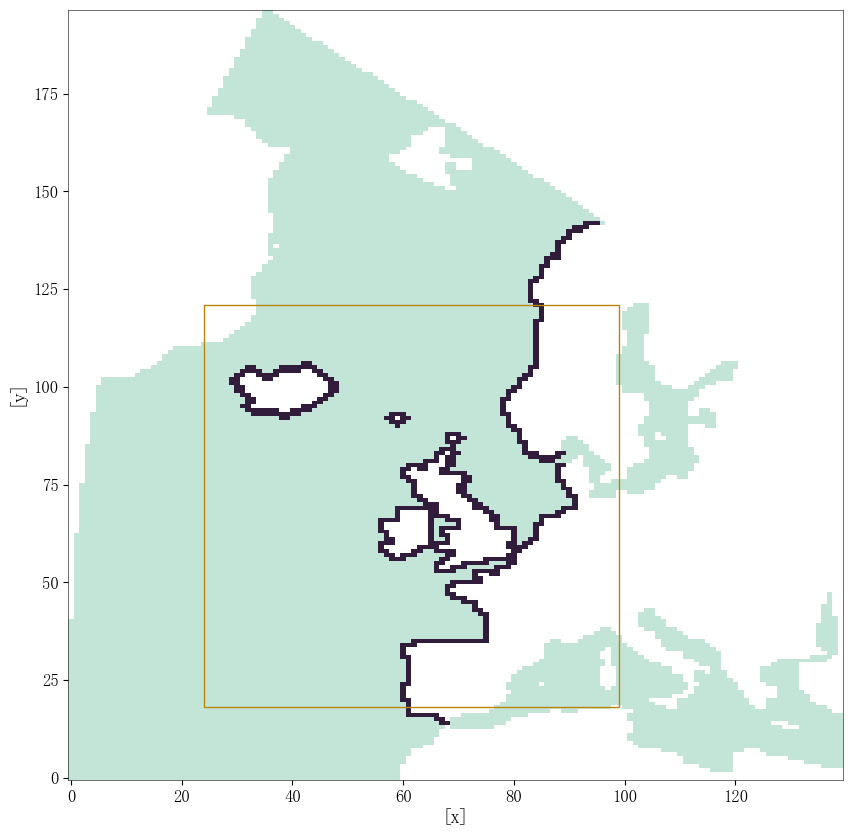

In [17]:

fig, ax = plt.subplots(
    figsize=(10, 10),
)

pcm = ax.pcolormesh(
    data.x, data.y, data,
    cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True),
    shading='auto',
)
rect = mpatches.Rectangle((24, 18), 75, 103, linewidth=1, edgecolor='darkgoldenrod', facecolor='none', label="Cropped area")
rect = ax.add_patch(rect)

ax.tick_params(
    axis='both',       # apply to both x and y axes
    which='both',      # major and minor ticks
    labelsize=12
#     bottom=False,      # remove bottom ticks
#     top=False,         # remove top ticks
#     left=False,        # remove left ticks
#     right=False,       # remove right ticks
#     labelbottom=False, # remove x-axis labels
#     labelleft=False    # remove y-axis labels
)
ax.set_ylabel('[y]', fontsize=14)
ax.set_xlabel('[x]', fontsize=14)
# y = list(range(0,197))
# x = list(range(0,140))

# ax.set_yticks(np.arange(min(y)+15, max(y), 40))
# labels_lat = [item.get_text() for item in ax.get_yticklabels()]
# ax.set_yticklabels(lat_label, fontsize=10)
# ax.set_ylabel('Latitude', fontsize=14)

# ax.set_xticks(np.arange(min(x), max(x),20))
# labels_lon = [item.get_text() for item in ax.get_xticklabels()]
# ax.set_xticklabels(lon_label, fontsize=10)
# ax.set_xlabel('Longitude', fontsize=14)

for location in ['left','bottom', 'right', 'top']:
    ax.spines[location].set_linewidth(0.4)

pass

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/alkalinityAddition.png')